In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
fl = pd.read_csv('cstJapa.csv')

# Multivariate : Random forest + AQV + WV

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Define Y and X, ensuring 'total_flu' is not in X to avoid data leakage
Y = fl['total_flu']
X = fl.drop(columns=['total_flu'])

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


# Define the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# Define a more focused parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300],  
    'max_depth': [5, 10, 15], 
    'min_samples_split': [10, 20, 30], 
    'min_samples_leaf': [2, 5, 10],  
    'max_features': ['sqrt', 'log2'],  
    'bootstrap': [True, False]  
}

# Use RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(estimator=rf_model, 
                                   param_distributions=param_dist, 
                                   n_iter=50,  # Fewer iterations for small dataset
                                   cv=5,       # 5-fold cross-validation
                                   verbose=2, 
                                   random_state=42, 
                                   n_jobs=-1)  # Use all available processors

# Fit the model
random_search.fit(X_train, y_train)

# Get the best estimator from RandomizedSearchCV
best_rf_model = random_search.best_estimator_

# Predict and calculate performance metrics
y_pred_rf = best_rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# Print the best parameters
print(f"Best parameters found: {random_search.best_params_}")

# Print the results
print(f"R-squared: {r2_rf:.3f}")
print(f"MSE: {mse_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15, 'bootstrap': False}
R-squared: 0.481
MSE: 158590.23
RMSE: 398.23
MAE: 218.59


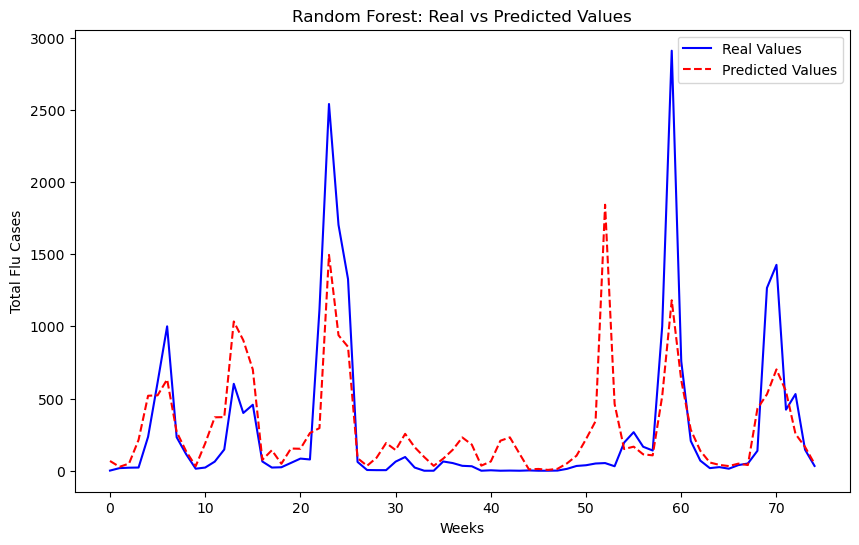

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by indices (if necessary, especially if your data is time-ordered)
sorted_indices = np.argsort(y_test.index)

# Ensure both y_test and y_pred_rf are sorted and aligned
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(y_test)), y_test.iloc[sorted_indices], label="Real Values", color='blue')
plt.plot(np.arange(len(y_pred_rf)), y_pred_rf[sorted_indices], label="Predicted Values", color='red', linestyle='--')  # Red dotted line for predictions
plt.title("Random Forest: Real vs Predicted Values")
plt.xlabel("Weeks")
plt.ylabel("Total Flu Cases")
plt.legend()
plt.show()


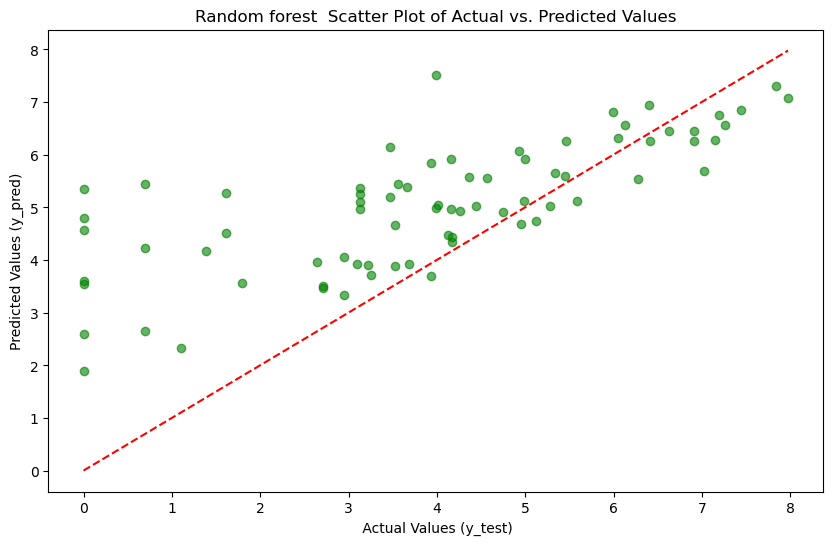

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Apply log transformation to both y_test and y_pred
y_test_log = np.log1p(y_test)  # log1p(x) is log(x + 1) to handle zeros
y_pred_log = np.log1p(y_pred_rf)

# Create scatter plot for log-transformed values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_log, y_pred_log, color='green', alpha=0.6)  # Green dots for scatter
plt.plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], color='red', linestyle='--')  # 45-degree line

# Add labels and title
plt.title("Random forest  Scatter Plot of Actual vs. Predicted Values")
plt.xlabel(" Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")

# Show plot
plt.show()


# RF + AQV

In [59]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Features and target
features = ['NO', 'PM2.5', 'SO2', 'CO']
target = 'total_flu'

# Step 1: Prepare the data
X = fl[features].values  # Feature matrix
y = fl[target].values  # Target variable


# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


# Define the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],  
    'max_depth': [5, 10, 15],  
    'min_samples_split': [10, 20, 30],  
    'min_samples_leaf': [2, 5, 10],  
    'max_features': ['sqrt', 'log2'], 
    'bootstrap': [True, False]  
}


# Use RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(estimator=rf_model, 
                                   param_distributions=param_dist, 
                                   n_iter=50,  # Fewer iterations for small dataset
                                   cv=5,       # 5-fold cross-validation
                                   verbose=2, 
                                   random_state=42, 
                                   n_jobs=-1)  # Use all available processors

# Fit the model
random_search.fit(X_train, y_train)

# Get the best estimator from RandomizedSearchCV
best_rf_model = random_search.best_estimator_

# Predict and calculate performance metrics
y_pred_rf = best_rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# Print the best parameters
print(f"Best parameters found: {random_search.best_params_}")

# Print the results
print(f"R-squared: {r2_rf:.3f}")
print(f"MSE: {mse_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
R-squared: 0.344
MSE: 200626.76
RMSE: 447.91
MAE: 249.73


# RF + WV

In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Features and target
features = ['Temperature', 'Wind_speed', 'Surface_Pressure', 'relative_humidity']
target = 'total_flu'

# Step 1: Prepare the data
X = fl[features].values  # Feature matrix
y = fl[target].values  # Target variable


# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


# Define the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300],  
    'max_depth': [5, 10, 15],  
    'min_samples_split': [10, 20, 30],  
    'min_samples_leaf': [2, 5, 10], 
    'max_features': ['sqrt', 'log2'],  
    'bootstrap': [True, False]  
}


# Use RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(estimator=rf_model, 
                                   param_distributions=param_dist, 
                                   n_iter=50,  # Fewer iterations for small dataset
                                   cv=5,       # 5-fold cross-validation
                                   verbose=2, 
                                   random_state=42, 
                                   n_jobs=-1)  # Use all available processors

# Fit the model
random_search.fit(X_train, y_train)

# Get the best estimator from RandomizedSearchCV
best_rf_model = random_search.best_estimator_

# Predict and calculate performance metrics
y_pred_rf = best_rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# Print the best parameters
print(f"Best parameters found: {random_search.best_params_}")

# Print the results
print(f"R-squared: {r2_rf:.3f}")
print(f"MSE: {mse_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found: {'n_estimators': 200, 'min_samples_split': 30, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 5, 'bootstrap': True}
R-squared: 0.161
MSE: 256430.59
RMSE: 506.39
MAE: 301.20
